<a href="https://colab.research.google.com/github/tanmayzalke26/Machine_Learning_Practicals/blob/main/MSPA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bagging Accuracy: 0.9333333333333333
Boosting Accuracy: 0.8966666666666666


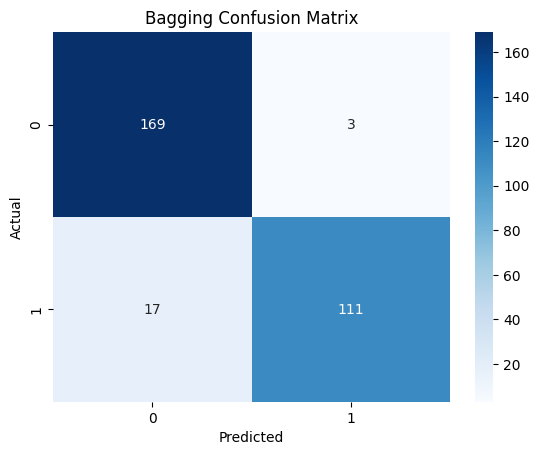

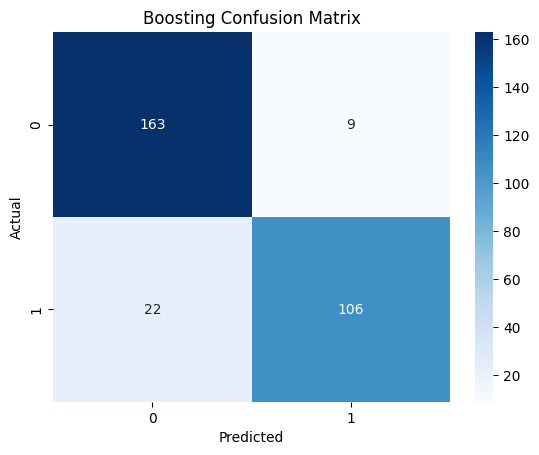

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

df = pd.read_csv('/content/customer_purchase_data.csv')
X = df.drop('PurchaseStatus', axis=1)
y = df['PurchaseStatus']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10, random_state=42)
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
print(f"Bagging Accuracy: {accuracy_bagging}")

boosting_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
boosting_model.fit(X_train, y_train)
y_pred_boosting = boosting_model.predict(X_test)
accuracy_boosting = accuracy_score(y_test, y_pred_boosting)
print(f"Boosting Accuracy: {accuracy_boosting}")

# Bagging Confusion Matrix
cm_bagging = confusion_matrix(y_test, y_pred_bagging)
sns.heatmap(cm_bagging, annot=True, fmt='d', cmap='Blues')
plt.title('Bagging Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Boosting Confusion Matrix
cm_boosting = confusion_matrix(y_test, y_pred_boosting)
sns.heatmap(cm_boosting, annot=True, fmt='d', cmap='Blues')
plt.title('Boosting Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

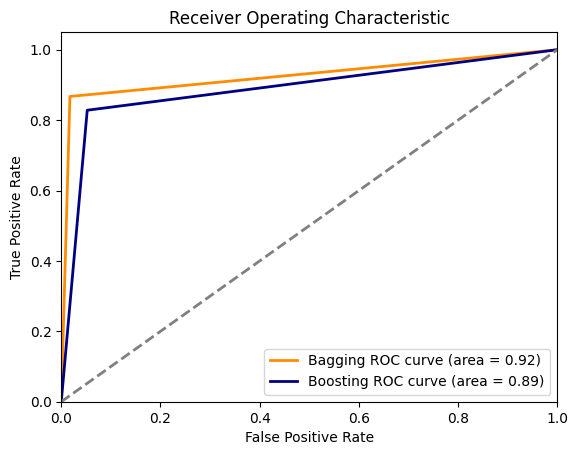

In [2]:
# Bagging ROC Curve
fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(y_test, y_pred_bagging)
roc_auc_bagging = auc(fpr_bagging, tpr_bagging)

# Boosting ROC Curve
fpr_boosting, tpr_boosting, thresholds_boosting = roc_curve(y_test, y_pred_boosting)
roc_auc_boosting = auc(fpr_boosting, tpr_boosting)

# Plot ROC curves
plt.figure()
plt.plot(fpr_bagging, tpr_bagging, color='darkorange', lw=2, label='Bagging ROC curve (area = %0.2f)' % roc_auc_bagging)
plt.plot(fpr_boosting, tpr_boosting, color='navy', lw=2, label='Boosting ROC curve (area = %0.2f)' % roc_auc_boosting)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

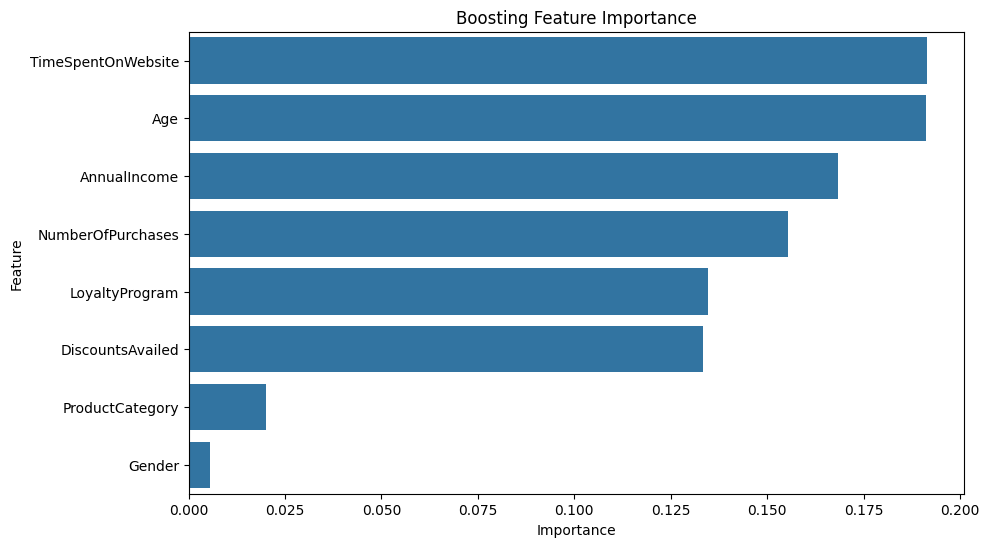

In [3]:
# Get feature importances from the boosting model
feature_importances = boosting_model.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Boosting Feature Importance')
plt.show()